# **Diabetes prediction**

# Pregled skupa podataka

Cilj projekta je razvoj i evaluacija modela mašinskog učenja za predviđanje pojave dijabetesa kod pacijenata na osnovu njihovih demografskih karakteristika, zdravstvenih parametara i životnih navika.

Kao dataset je korišćen skup podataka *diabetes_prediction_dataset.csv* preuzet sa Kaggle-a. 

U dataset-u se nalaze oko 100000 primera sa 9 atributa koji opisuju zdravstveno stanje i životne navike ljudi. Dataset sadrži kombinaciju numeričkih, kategorijskih i binarnih atributa, pri čemu je ciljna promenljiva Diabetes binarnog tipa i označava prisustvo ili odsustvo dijabetesa kod pacijenta.

| Karakteristika | Tip podataka | Opis |
|---------------|--------------------|-----|
| Gender | Kategorijski |Pol pacijenta |
| Age | Numerički| Starost pacijenta u godinama |
| Hypertension | Binarni (0/1) | Visok krvni pritisak (0 = ne, 1 = da) |
| Heart Disease | Binarni (0/1) | Srčane bolesti (0 = ne, 1 = da) |
| Smoking History | Kategorijski | Istorija pušenja |
| BMI | Numerički | Numeri Indeks telesne mase |
| HbA1c Level | Numerički | Prosečan nivo šećera u krvi |
| Blood Glucose Level | Numerički | Trenutni nivo glukoze u krvi |
| Diabetes | Binarni (0/1) | Ciljna promenljiva (1 = prisustvo dijabetesa, 0 = nema dijabetesa)|


## EDA

U okviru eksplorativne analize podataka (EDA) izvršena je osnovna analiza strukture skupa podataka, provera nedostajućih vrednosti, uklanjanje duplikata i izračunavanje deskriptivnih statističkih mera.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [3]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Nema nedostajućih vrednosti. 

In [6]:
print("Broj duplikata u dataset-u: ", df.duplicated().sum())

Broj duplikata u dataset-u:  3854


In [7]:
#uklanjanje duplikata
df = df.drop_duplicates()
print("Dimenzije podataka nakon uklanjanja duplikata:", df.shape)

Dimenzije podataka nakon uklanjanja duplikata: (96146, 9)


In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


Nakon osnovne analize i čišćenja podataka, u nastavku je sprovedena vizuelna eksplorativna analiza radi detaljnijeg uvida u raspodelu i međusobne odnose atributa.

## Analiza ciljne promenljive

In [9]:
df["diabetes"].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

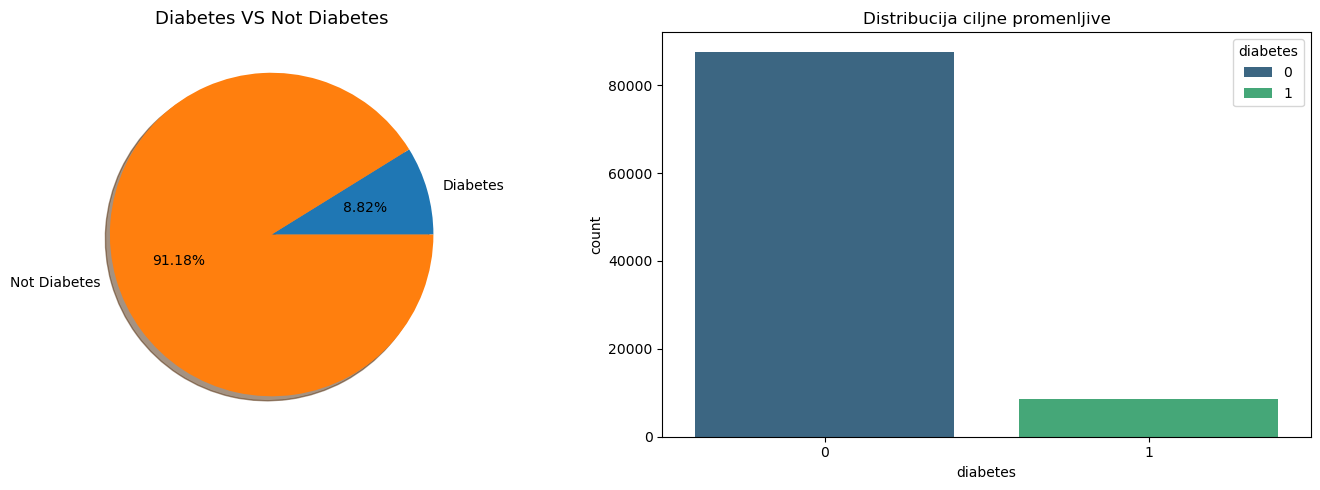

In [10]:
diabetes_count = df['diabetes'].value_counts()[1]
not_diabetes_count = df['diabetes'].value_counts()[0]
sizes = [diabetes_count, not_diabetes_count]
labels = ['Diabetes', 'Not Diabetes']
fig, ax = plt.subplots(1,2,figsize=(14, 5))

ax[0].pie(sizes, labels=labels, shadow=True, autopct='%1.2f%%')
ax[0].set_title("Diabetes VS Not Diabetes", size=13)

sns.countplot(x='diabetes', hue='diabetes', data=df, palette='viridis',ax=ax[1])
ax[1].set_title('Distribucija ciljne promenljive')
plt.tight_layout()
plt.show()

Analiza distribucije ciljne promenljive (Diabetes) pokazuje da postoji **disbalans** klasa, pri čemu je značajno više instanci pacijenata bez dijabetesa u odnosu na one sa dijabetesom. Ovaj disbalans može uticati na performanse modela mašinskog učenja, posebno kod standardnih klasifikatora, te se preporučuje razmatranje tehnika za balansiranje klasa, kao što su oversampling i undersampling.

## Histogrami

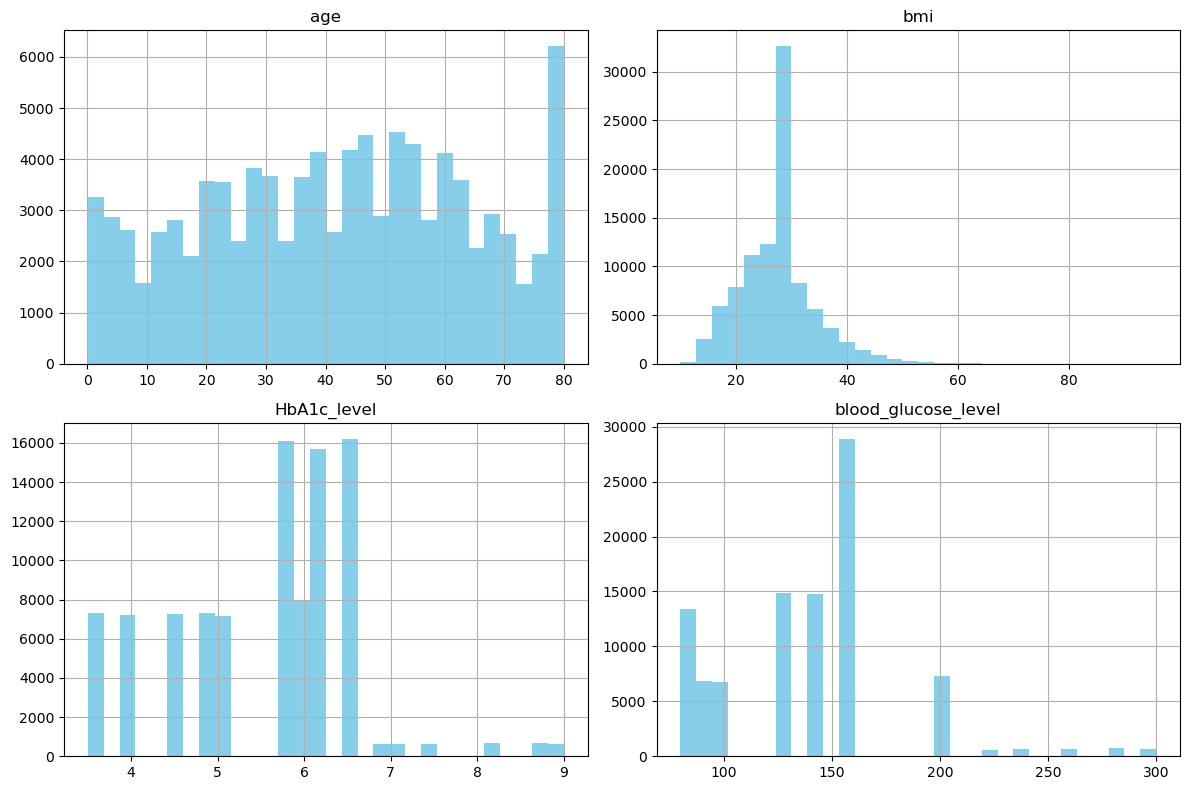

In [11]:
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
df[numeric_features].hist(bins=30, figsize=(12,8), color='skyblue')

plt.tight_layout()
plt.show()

Analizom histograma ključnih numeričkih atributa dobijen je uvid u raspodelu vrednosti. Starost ispitanika je pretežno koncentrisana u srednjim godinama, dok BMI pokazuje blagu desnu asimetriju, što ukazuje na prisustvo pacijenata sa povišenom telesnom masom. Raspodele HbA1c i nivoa glukoze u krvi imaju manji broj visokih vrednosti, što je u skladu sa postojanjem disbalansa u ciljnoj promenljivoj. Ovi uvidi su značajni za dalje korake predobrade i izgradnje modela. 

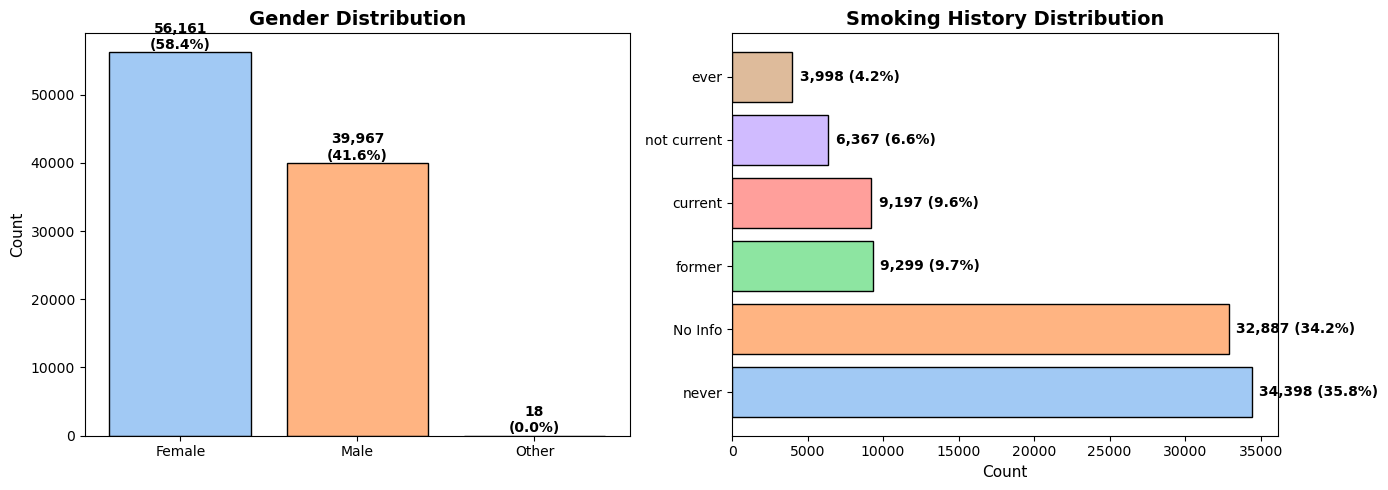

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender Distribution
gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=sns.color_palette('pastel'), edgecolor='black')
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')


# Smoking History Distribution  
smoking_counts = df['smoking_history'].value_counts()
axes[1].barh(smoking_counts.index, smoking_counts.values, color=sns.color_palette('pastel', len(smoking_counts)), edgecolor='black')
axes[1].set_title('Smoking History Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
for i, v in enumerate(smoking_counts.values):
    axes[1].text(v + 500, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontweight='bold')


plt.tight_layout()
plt.show()

Grafički prikaz distribucije pola pokazuje da je skup podataka relativno uravnotežen u pogledu zastupljenih muških i ženskih ispitanika. S obzirom da je kategorija *Other* izuzetno slabo zastupljena, odlučeno je da se iz analize izostavi. Nakon toga je pol konvertovan u binranu promenljivu. Distribucija istorije pušenja ukazuje da najveći deo ispitanika nikada nije pušilo ili spada u kategoriju bivših pušača, dok su ostale kategorije manje zastupljene. 

In [13]:
df = df[df.gender != "Other"]
set(df.gender)
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,never,25.19,6.6,140,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0
2,1,28.0,0,0,never,27.32,5.7,158,0
3,0,36.0,0,0,current,23.45,5.0,155,0
4,1,76.0,1,1,current,20.14,4.8,155,0


In [14]:
df.describe().style.format("{:.2f}")

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00
mean,0.42,41.80,0.08,0.04,27.32,5.53,138.22,0.09
std,0.49,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.00,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,0.00,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,0.00,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,1.00,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,1.00,80.00,1.00,1.00,95.69,9.00,300.00,1.00


## Boxplot analiza

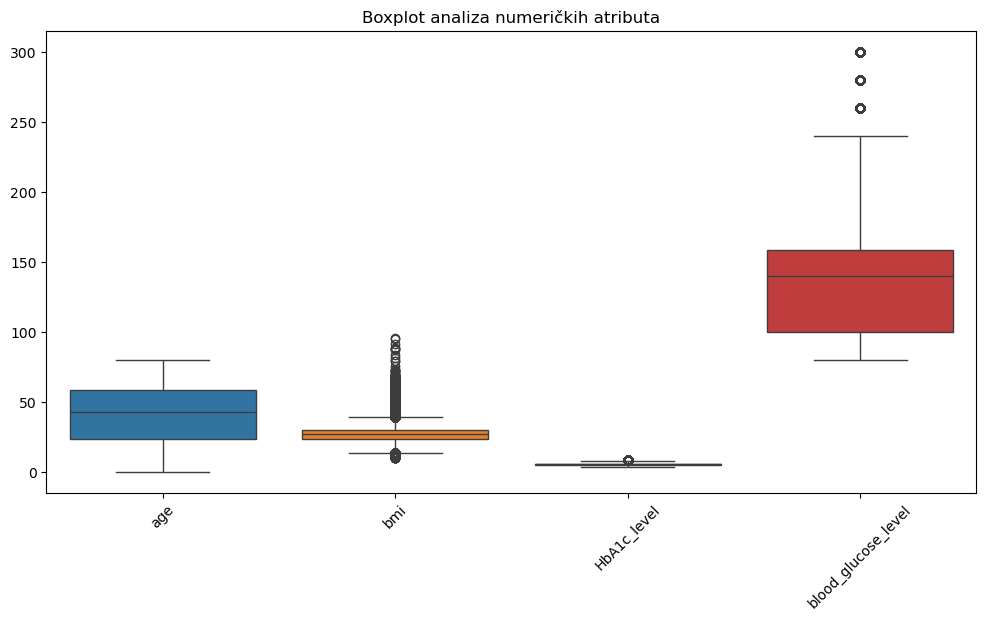

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=45)
plt.title("Boxplot analiza numeričkih atributa")
plt.show()

Na osnovu boxplot analize numeričkih atributa (age, BMI, HbA1c level i blood glucose level) uočen je određeni broj ekstremnih vrednosti. Najizraženiji outlieri prisutni su kod atributa BMI, HbA1c level i blood glucose level, što ukazuje na postojanje ispitanika sa izrazito povišenim ili sniženim vrednostima ovih zdravstvenih parametara.

Prisustvo outliera je očekivano u medicinskim skupovima podataka i ne mora predstavljati greške u podacima, već može ukazivati na klinički relevantne slučajeve. Zbog toga ekstremne vrednosti nisu uklonjene, već su zadržane za dalju analizu i modelovanje, kako se ne bi izgubile informacije. 

Detektovani outlieri nisu uklonjeni iz skupa podataka, već su ograničeni (capped) na odgovarajuće granice kako bi se smanjio njihov uticaj na modele.

age: detektovano 0 outliera
bmi: detektovano 5354 outliera
HbA1c_level: detektovano 1312 outliera
blood_glucose_level: detektovano 2031 outliera


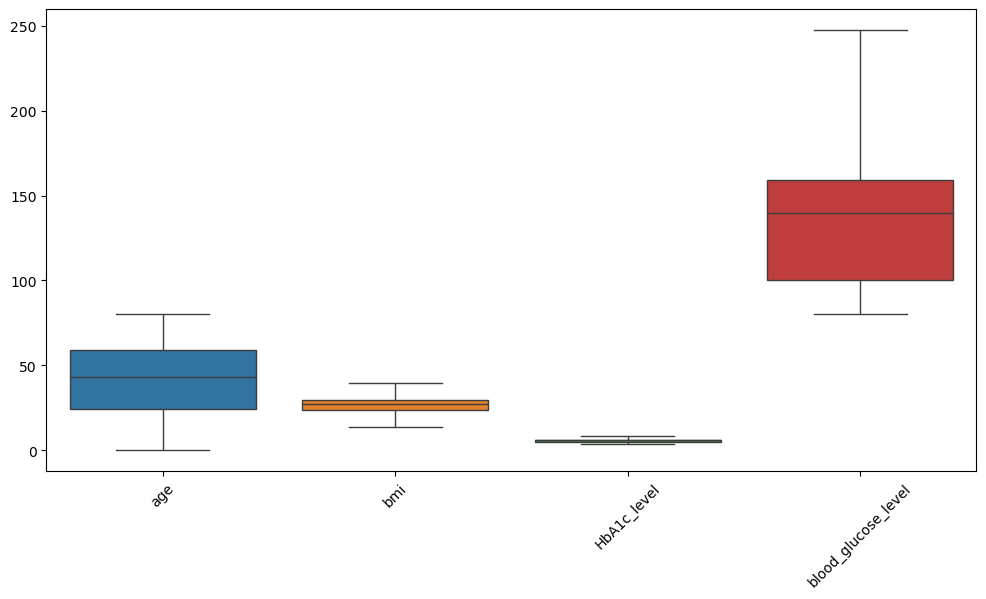

In [16]:
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    
    print(f"{column}: detektovano {outliers} outliera")
    
    data[column] = data[column].clip(lower_bound, upper_bound)

    return data

for col in ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']:
    df = cap_outliers(df, col)
    
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=45)
plt.show()

## Pair plot analiza 

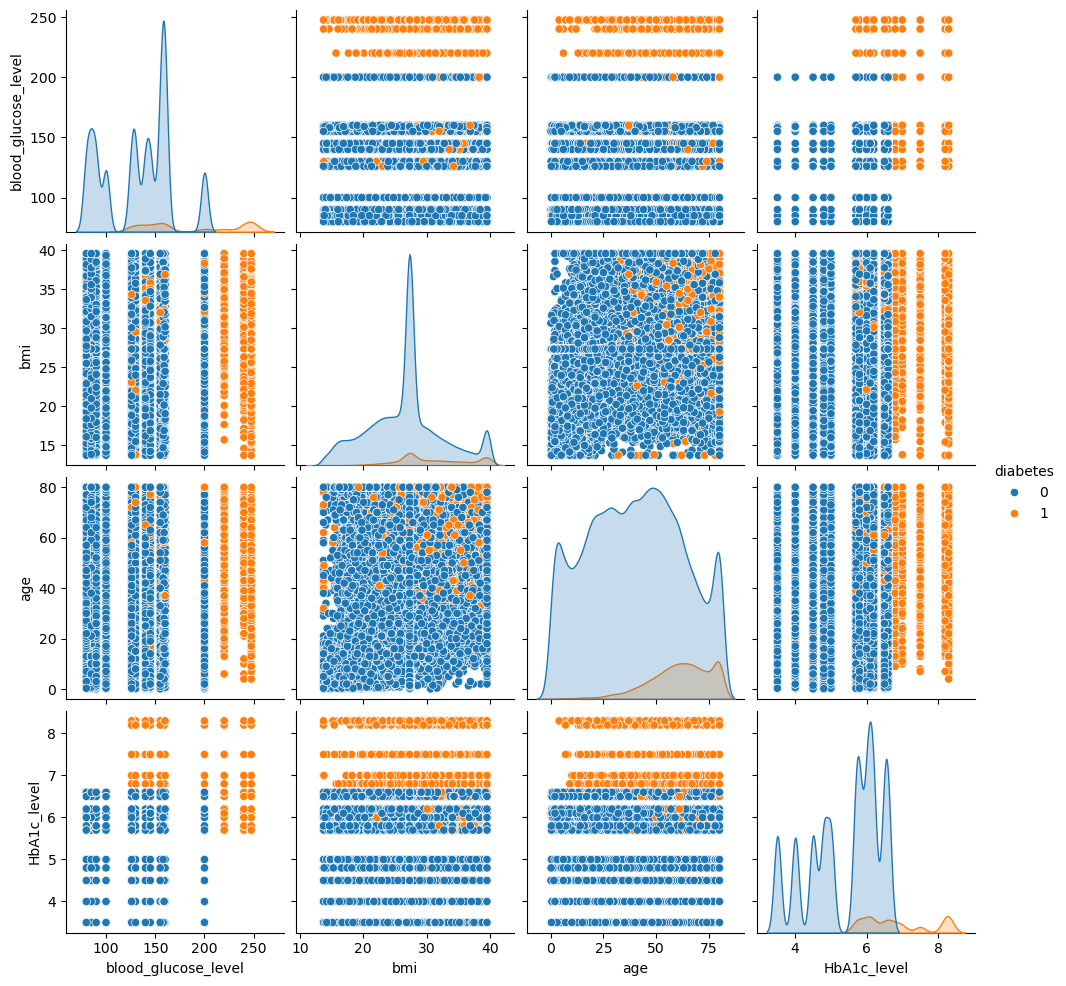

In [17]:
sns.pairplot(df[['blood_glucose_level', 'bmi', 'age', 'HbA1c_level', 'diabetes']], hue='diabetes')
plt.show()

Pair plot analiza omogućila je vizuelno ispitivanje odnosa između pojedinačnih karakteristika i ciljne promenljive. Uočeno je da se klase sa i bez dijabetesa jasno razdvajaju u prostoru atributa HbA1c nivoa i nivoa glukoze u krvi, što potvrđuje njihovu visoku diskriminativnu moć. Sa druge strane, atributi poput starosti i BMI pokazuju značajno preklapanje klasa, što ukazuje da sami po sebi nisu dovoljni za preciznu klasifikaciju, ali mogu doprineti modelu u kombinaciji sa drugim faktorima. 

### Analiza binarnih kliničkih identikatora

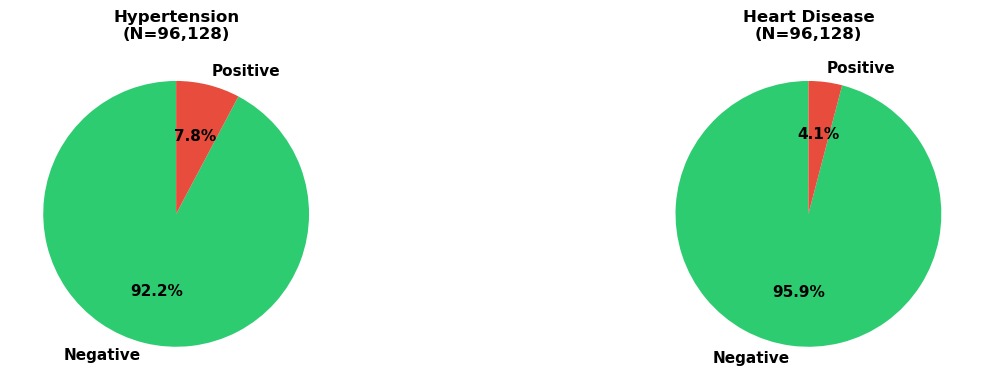

In [18]:
binary_features = ['hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for idx, feature in enumerate(binary_features):
    counts = df[feature].value_counts()
    colors = ['#2ecc71', '#e74c3c']
    
    axes[idx].pie(counts, labels=['Negative', 'Positive'], autopct='%1.1f%%', 
                  colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[idx].set_title(f'{feature.replace("_", " ").title()}\n(N={len(df):,})', 
                        fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Analiza binarnih kliničkih indikatora pokazuje da većina ispitanika nema hipertenziju ni srčane bolesti. Uočen disbalans klasa ukazuje na potrebu za pažljivim izborom evaluacionih metrika tokom modelovanja.

## Korelaciona matrica

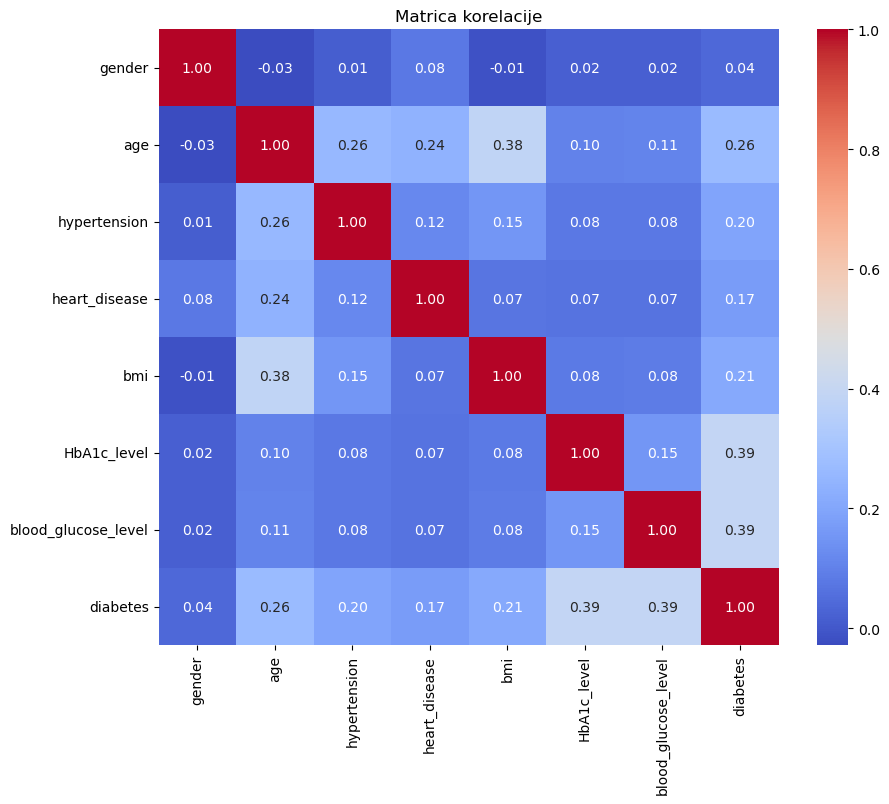

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrica korelacije")
plt.show()

Analiza korelacione matrice pokazuje da su najjače pozitivne korelacije prisutne između HbA1c nivoa, nivoa glukoze u krvi i ciljne promenljive dijabetes. Korelacije između dijabetesa i demografskih ili binarnih kliničkih indikatora (age, hypertension, heart_disease) su slabije, ali i dalje informativne, što znači da dijabetes zavisi od kombinacije više faktora, a ne od jednog pojedinačnog atributa.

## **Priprema podataka**

## Kodiranje podataka

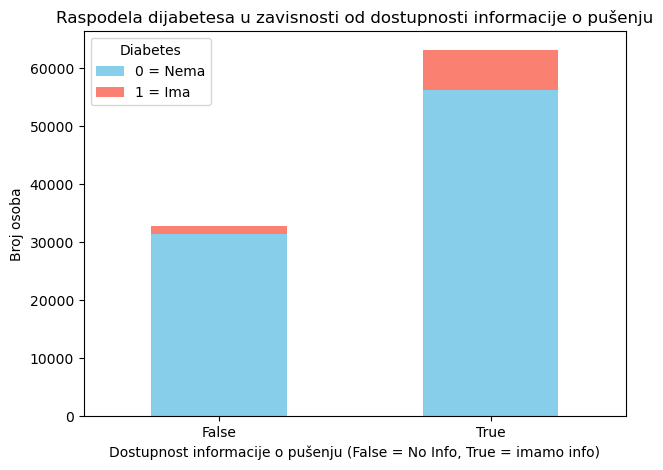

In [20]:
df['has_smoking_info'] = df['smoking_history'] != 'No Info'

info_counts = df.groupby(['has_smoking_info', 'diabetes']).size().unstack(fill_value=0)

info_percent = df.groupby('has_smoking_info')['diabetes'].value_counts(normalize=True).unstack(fill_value=0) * 100

info_counts = df.groupby(['has_smoking_info', 'diabetes']).size().unstack(fill_value=0)

# Plot
info_counts.plot(kind='bar', stacked=True, figsize=(7,5), color=['skyblue','salmon'])
plt.title("Raspodela dijabetesa u zavisnosti od dostupnosti informacije o pušenju")
plt.xlabel("Dostupnost informacije o pušenju (False = No Info, True = imamo info)")
plt.ylabel("Broj osoba")
plt.legend(title='Diabetes', labels=['0 = Nema', '1 = Ima'])
plt.xticks(rotation=0)
plt.show()


In [21]:
def simplify_smoking(status):
    if status in ['never', 'No Info']:
        return 0  # Označavamo ih kao "Nizak rizik"
    else:
        return 1  # Svi ostali (pušači i bivši) su "Povišen rizik"

df['smoking_history'] = df['smoking_history'].apply(simplify_smoking)
if 'has_smoking_info' in df.columns:
    df = df.drop('has_smoking_info', axis=1)

print(df['smoking_history'].value_counts())
df.head()

smoking_history
0    67276
1    28852
Name: count, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140.0,0
1,0,54.0,0,0,0,27.32,6.6,80.0,0
2,1,28.0,0,0,0,27.32,5.7,158.0,0
3,0,36.0,0,0,1,23.45,5.0,155.0,0
4,1,76.0,1,1,1,20.14,4.8,155.0,0


Promenljiva *smoking_history* je inicijalno sadržala više kategorija, uključujući never, current, former, ever, not current i No Info. Analizom je uočeno da kategorija No Info nije nasumično raspoređena, već je dominantno prisutna kod ispitanika bez dijabetesa, što može dovesti do pristrasnosti modela i narušavanja generalizacije. Zbog toga je izvršena pojednostavljena rekategorizacija promenljive smoking_history u binarnu formu, u skladu sa kliničkom interpretacijom rizika:

-vrednost 0 označava ispitanike koji nikada nisu pušili ili za koje nema dostupnih informacija (never, No Info), i tretirani su kao grupa sa nižim rizikom,

-vrednost 1 obuhvata sve ispitanike sa istorijom pušenja (current, former, ever, not current), koji su označeni kao grupa sa povišenim zdravstvenim rizikom.

Ovakva transformacija smanjuje šum u podacima, pojednostavljuje model i omogućava algoritmu da se fokusira na klinički relevantnu informaciju o izloženosti pušenju, umesto na administrativne razlike u dostupnosti podataka. 

## **Podela na test i trening podatke**

In [22]:

X = df.drop('diabetes', axis=1)
y = df['diabetes']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(df.shape)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
X_train.head()

(96128, 9)
Training set shape: (76902, 8)
Testing set shape: (19226, 8)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
12312,0,22.0,0,0,0,24.12,6.1,100.0
51981,0,69.0,0,1,1,28.45,8.3,247.5
62671,1,31.0,0,0,0,20.67,6.6,200.0
33823,1,59.0,0,0,0,27.16,8.2,160.0
44586,0,24.0,0,0,0,22.65,6.2,140.0


In [24]:
scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

## PCA pre SMOTETomek-a

U cilju razumevanja kompleksnosti problema, primenjena je tehnika Analize glavnih komponenti (PCA) kako bi se osam dimenzija (atributa) projektovalo u dvodimenzionalni prostor. Kao što se na grafiku vidi, klase pacijenata sa i bez dijabetesa pokazuju **visok stepen preklapanja u 2D prostoru**. Ovo je ključni dokaz da granica između zdravlja i bolesti nije linearna i jednostavna. Upravo ova isprepletenost opravdava korišćenje naprednih algoritama poput Random Forest-a, koji mogu da pronađu kompleksne granice koje PCA (kao linearna metoda) ne može lako da razdvoji.

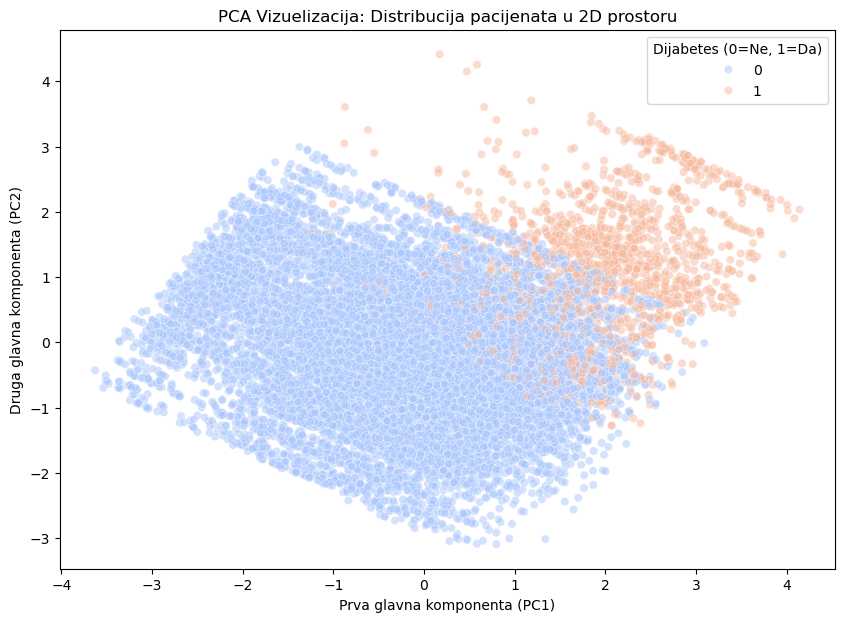

In [25]:
from sklearn.decomposition import PCA

X_test_numeric = X_test[numeric_features]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_numeric)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_test, palette='coolwarm', alpha=0.5)

plt.title("PCA Vizuelizacija: Distribucija pacijenata u 2D prostoru")
plt.xlabel("Prva glavna komponenta (PC1)")
plt.ylabel("Druga glavna komponenta (PC2)")
plt.legend(title='Dijabetes (0=Ne, 1=Da)')
plt.show()

Da bismo modelima olakšali pronalaženje granice odlučivanja, koristili smo SMOTETomek hibridnu metodu. Ona kombinuje oversampling manjinske klase sa eliminacijom 'Tomek linkova' – parova podataka koji stvaraju šum na samoj granici klasa.

## SMOTETomek 

In [26]:
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from collections import Counter

smt = SMOTETomek(
    smote=SMOTE(sampling_strategy=0.5, random_state=42), 
    random_state=42
)

X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print(f"Originalni balans: {Counter(y_train)}")
print(f"Balans nakon SMOTETomek: {Counter(y_train_res)}")

Originalni balans: Counter({0: 70116, 1: 6786})
Balans nakon SMOTETomek: Counter({0: 69483, 1: 34425})


Primenom *SMOTETomek* metode postignuta je jasnija separacija u prostoru obeležja. U našem slučaju, broj uzoraka bolesnih pacijenata je značajno povećan (sa 6.786 na 34.425), dok je eliminacijom Tomek linkova uklonjen šum koji je zbunjivao model.

## PCA posle SMOTETomek-a

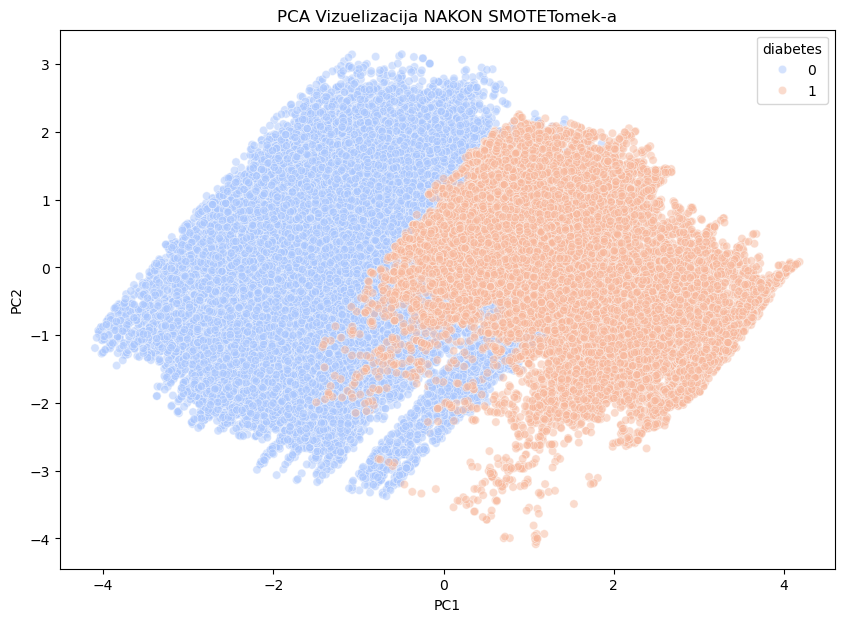

In [27]:
from sklearn.decomposition import PCA

# PCA nad balansiranim podacima
pca_res = PCA(n_components=2)
X_pca_res = pca_res.fit_transform(X_train_res)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_res[:, 0], y=X_pca_res[:, 1], hue=y_train_res, palette='coolwarm', alpha=0.5)
plt.title("PCA Vizuelizacija NAKON SMOTETomek-a")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Uporedna PCA analiza potvrđuje opravdanost korišćenja SMOTETomek metode. Dok je na originalnom datasetu granica između klasa bila difuzna, nakon tretmana podaci pokazuju jasniju linearnu i nelinearnu separabilnost, što direktno doprinosi stabilnosti i preciznosti finalnog klasifikatora.

## Implementacija i treniranje modela

In [28]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
def evaluate_model(model, X_test_data, y_test_true, name):
    
    y_probs = model.predict_proba(X_test_data)[:, 1]

    precision_pts, recall_pts, thresholds = precision_recall_curve(y_test_true, y_probs)
    f1_scores = 2 * (precision_pts * recall_pts) / (precision_pts + recall_pts + 1e-9)
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"\n{name}")
    print(f"Najbolji threshold (max F1): {best_threshold:.4f}")
    print(f"Najbolji F1 na tom threshold-u: {best_f1:.4f}")

    y_pred = (y_probs >= best_threshold).astype(int)
    
    metrics = {
        "Accuracy": accuracy_score(y_test_true, y_pred),
        "Precision": precision_score(y_test_true, y_pred),
        "Recall": recall_score(y_test_true, y_pred),
        "F1": f1_score(y_test_true, y_pred),
        "ROC-AUC": roc_auc_score(y_test_true, y_probs),
        "PR-AUC": average_precision_score(y_test_true, y_probs)  
    }
    
    print(f"\n{name} Results")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")
    

    if hasattr(model, 'coef_'):
        importance_values = model.coef_[0]
        label = "Coefficient"
    elif hasattr(model, 'feature_importances_'):
        importance_values = model.feature_importances_
        label = "Importance"
    else:
        importance_values = None

    if importance_values is not None:
        importance_df = pd.DataFrame({
            "Feature": X_test_data.columns,
            label: importance_values
        }).sort_values(label, ascending=False)
        print(f"\n--- RANG LISTA ATRIBUTA ({name}) ---")
        print(importance_df.head(10))
  
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Matrica konfuzije
    cm = confusion_matrix(y_test_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False, ax=ax[0])
    ax[0].set_title(f"Confusion Matrix: {name}")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")

    # 2. ROC Kriva
    fpr, tpr, _ = roc_curve(y_test_true, y_probs)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_title("ROC Curve")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].legend(loc="lower right")

    # 3. Precision-Recall Kriva 
    precision_pts, recall_pts, _ = precision_recall_curve(y_test_true, y_probs)
    avg_prec = average_precision_score(y_test_true, y_probs)
    ax[2].plot(recall_pts, precision_pts, color='green', lw=2, label=f'Avg Precision = {avg_prec:.2f}')
    ax[2].set_title("Precision-Recall Curve")
    ax[2].set_xlabel("Recall")
    ax[2].set_ylabel("Precision")
    ax[2].legend(loc="upper right")

    plt.tight_layout()
    plt.show()
  
    
    return metrics, best_threshold


### Baseline model - Logistička regresija


Baseline
Najbolji threshold (max F1): 0.8414
Najbolji F1 na tom threshold-u: 0.7170

Baseline Results
Accuracy: 0.9565
Precision: 0.8418
Recall: 0.6244
F1: 0.7170
ROC-AUC: 0.9585
PR-AUC: 0.8037

--- RANG LISTA ATRIBUTA (Baseline) ---
               Feature  Coefficient
6          HbA1c_level     2.386085
7  blood_glucose_level     1.313670
1                  age     1.209670
2         hypertension     0.831996
5                  bmi     0.741034
3        heart_disease     0.671185
0               gender     0.287347
4      smoking_history     0.235914


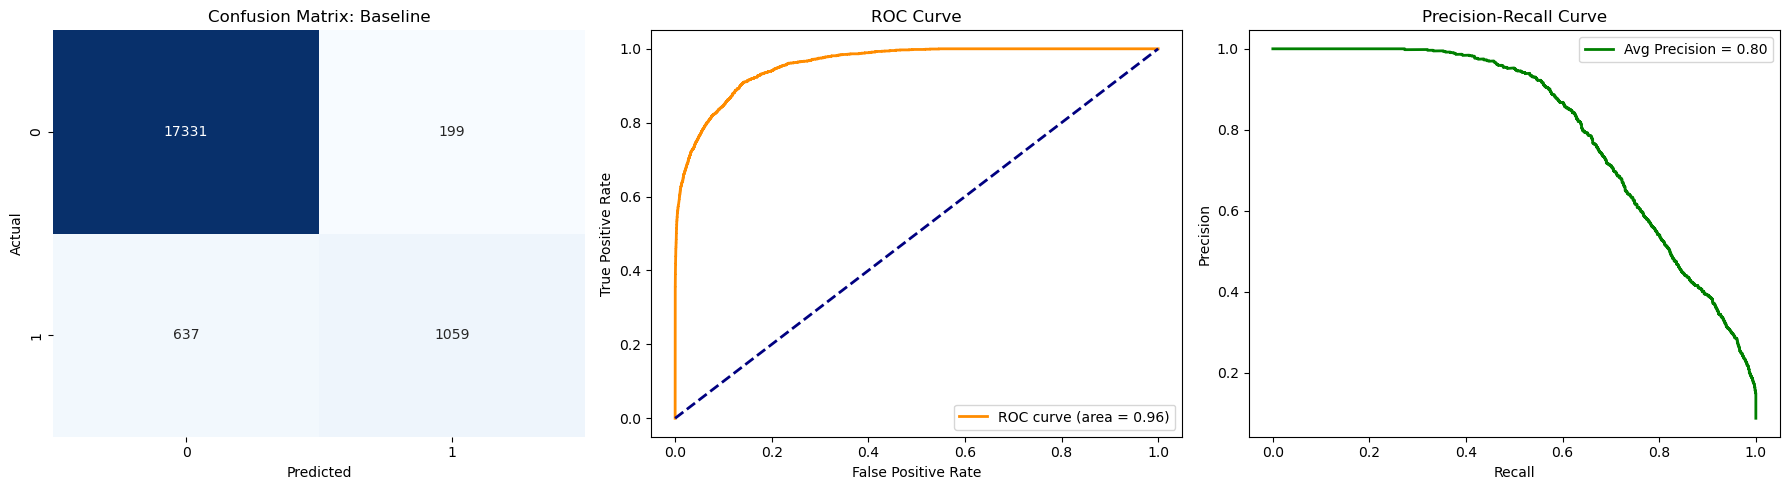

In [29]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

    
baseline_results = evaluate_model(model, X_test, y_test, "Baseline")

## Random Forest


Random Forest
Najbolji threshold (max F1): 0.8900
Najbolji F1 na tom threshold-u: 0.8071

Random Forest Results
Accuracy: 0.9713
Precision: 0.9906
Recall: 0.6810
F1: 0.8071
ROC-AUC: 0.9594
PR-AUC: 0.8490

--- RANG LISTA ATRIBUTA (Random Forest) ---
               Feature  Importance
6          HbA1c_level    0.373413
7  blood_glucose_level    0.303269
1                  age    0.172682
5                  bmi    0.102276
2         hypertension    0.023676
3        heart_disease    0.013039
4      smoking_history    0.006474
0               gender    0.005171


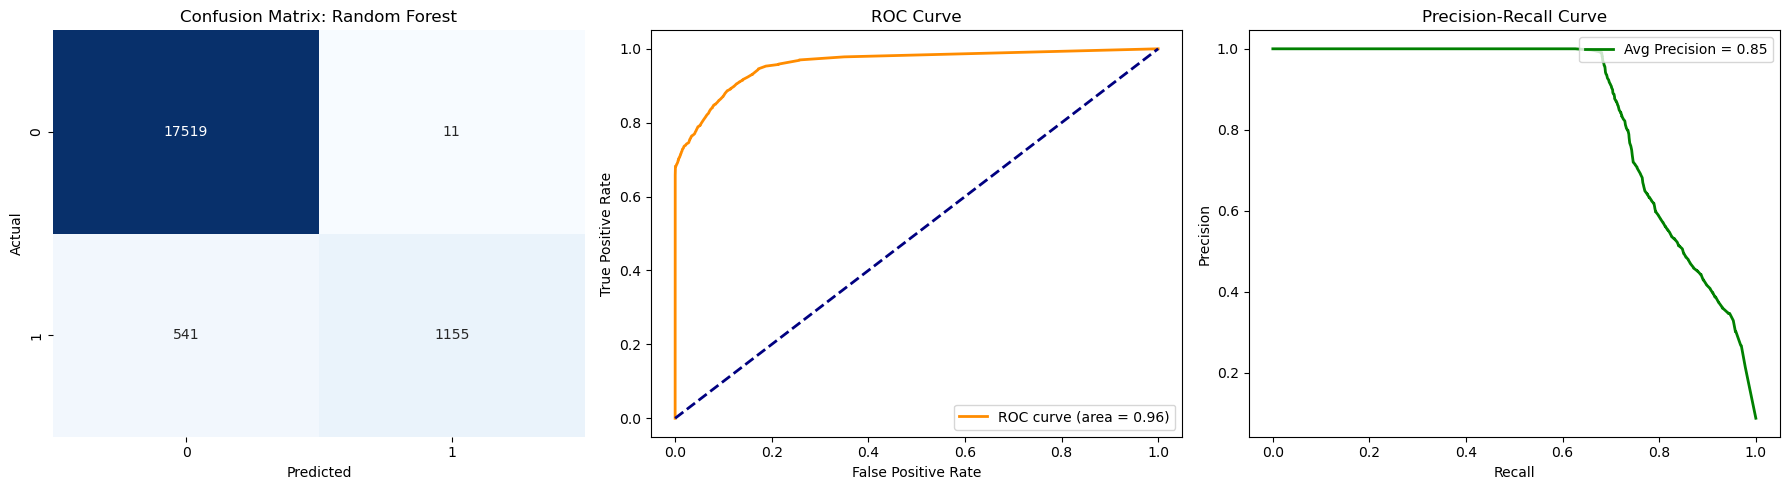

In [30]:
rs_model= RandomForestClassifier(n_estimators=100, random_state=42)
rs_model.fit(X_train_res, y_train_res)

rf_results = evaluate_model(rs_model, X_test, y_test, "Random Forest")

## SVM


Linear SVM (Fast)
Najbolji threshold (max F1): 0.8296
Najbolji F1 na tom threshold-u: 0.7179

Linear SVM (Fast) Results
Accuracy: 0.9559
Precision: 0.8248
Recall: 0.6356
F1: 0.7179
ROC-AUC: 0.9585
PR-AUC: 0.8033


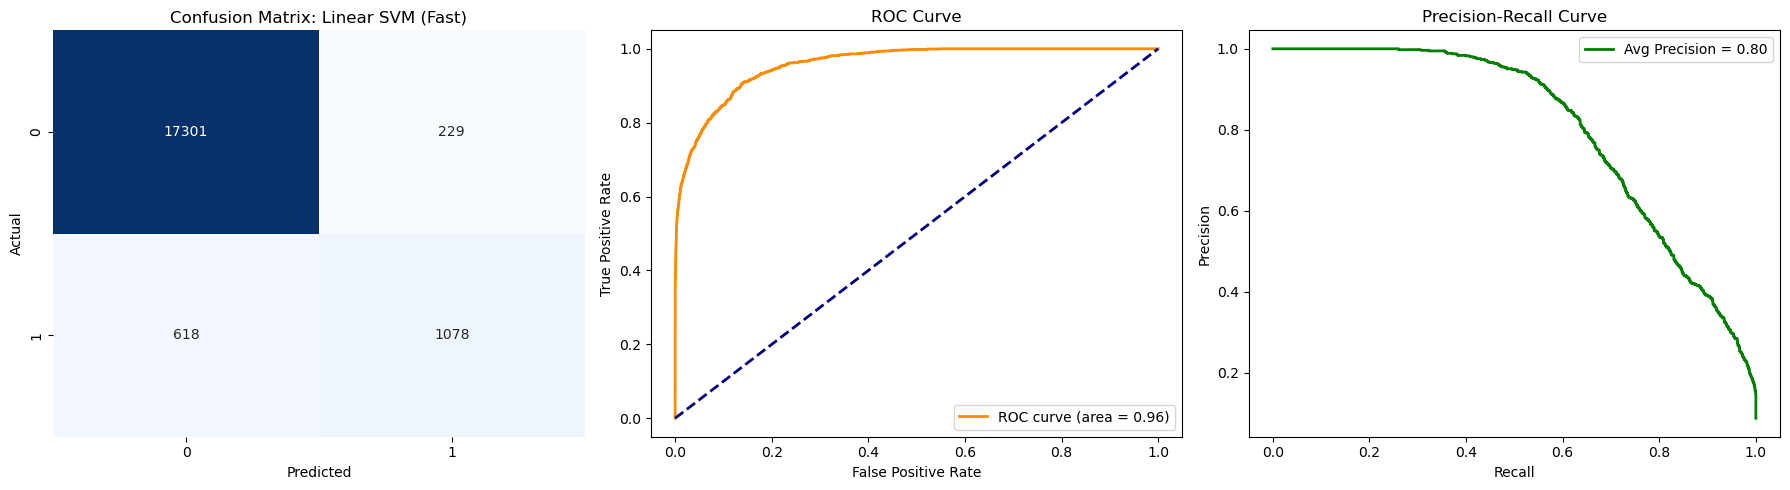

In [31]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(max_iter=2000, random_state=42)
svm_fast = CalibratedClassifierCV(base_svm) 

svm_fast.fit(X_train_res, y_train_res)
svm_results = evaluate_model(svm_fast, X_test, y_test, "Linear SVM (Fast)")

## XGBoost


XGBoost
Najbolji threshold (max F1): 0.9733
Najbolji F1 na tom threshold-u: 0.8100

XGBoost Results
Accuracy: 0.9718
Precision: 0.9991
Recall: 0.6810
F1: 0.8100
ROC-AUC: 0.9736
PR-AUC: 0.8689

--- RANG LISTA ATRIBUTA (XGBoost) ---
               Feature  Importance
6          HbA1c_level    0.526354
7  blood_glucose_level    0.266315
1                  age    0.068837
2         hypertension    0.050232
3        heart_disease    0.032263
5                  bmi    0.025085
0               gender    0.018034
4      smoking_history    0.012880


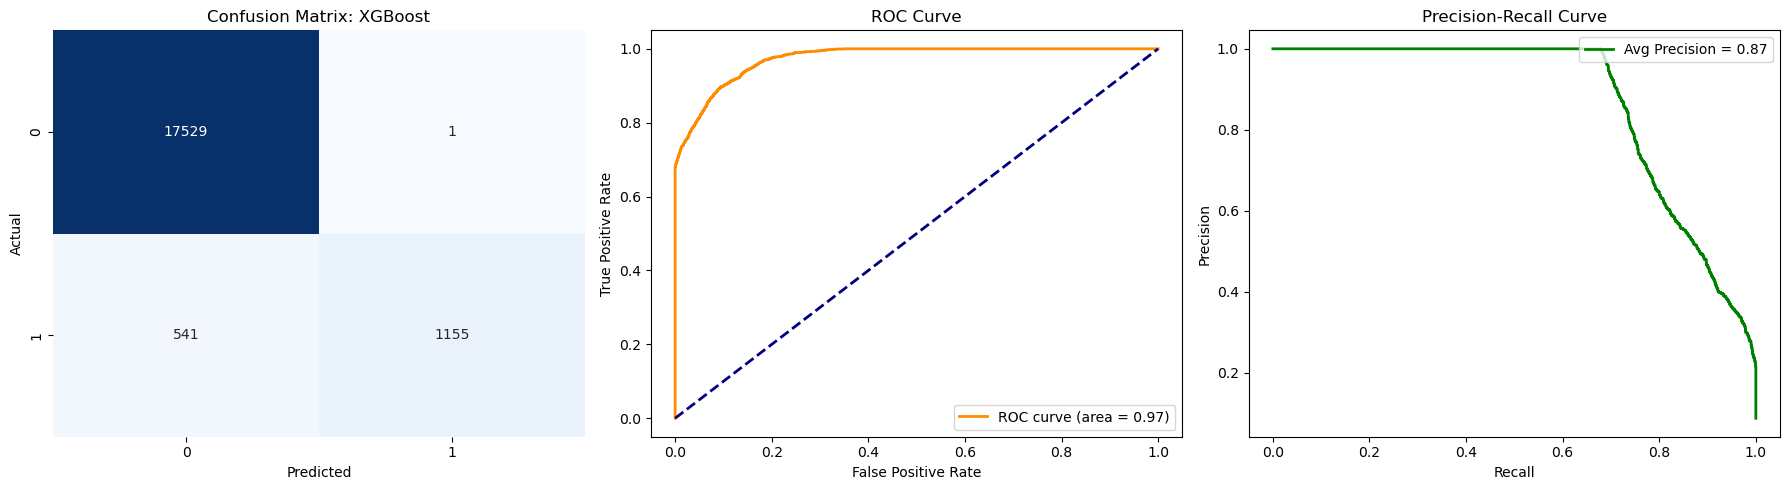

In [32]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False,scale_pos_weight=10, eval_metric='mlogloss')
xgb_model.fit(X_train_res, y_train_res)

xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

## CatBoost


CatBoost
Najbolji threshold (max F1): 0.8950
Najbolji F1 na tom threshold-u: 0.8119

CatBoost Results
Accuracy: 0.9720
Precision: 0.9949
Recall: 0.6857
F1: 0.8119
ROC-AUC: 0.9751
PR-AUC: 0.8728

--- RANG LISTA ATRIBUTA (CatBoost) ---
               Feature  Importance
6          HbA1c_level   50.213525
7  blood_glucose_level   38.008507
1                  age    6.866434
5                  bmi    3.107457
2         hypertension    0.509950
0               gender    0.474987
4      smoking_history    0.434444
3        heart_disease    0.384696


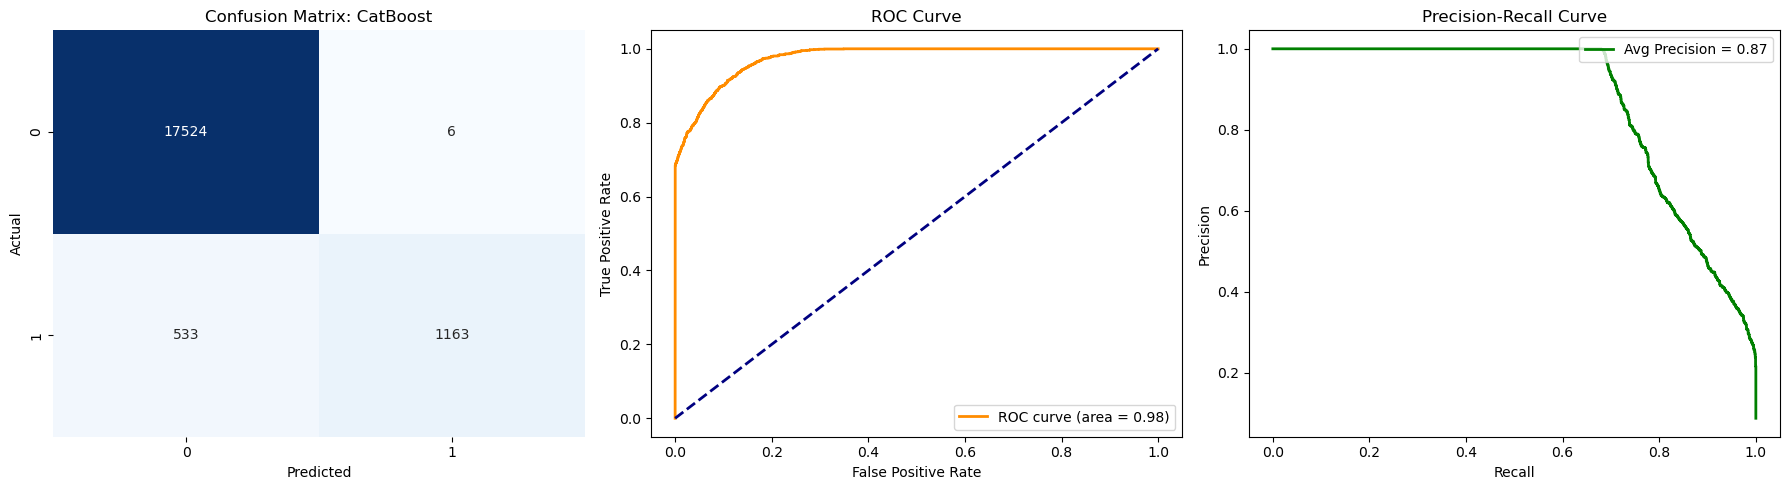

In [33]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500, 
    random_seed=42, 
    verbose=0,
    scale_pos_weight=3 
)

cat_model.fit(X_train_res, y_train_res)

cat_results = evaluate_model(cat_model, X_test, y_test, "CatBoost")

## Optimizacija hiperparametara

In [34]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import RandomizedSearchCV

In [35]:
models_to_tune = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "class_weight": ['balanced', None]
        }
    },
    "CatBoost": {
        "model": CatBoostClassifier(verbose=0, random_seed=42),
        "params": {
            "iterations": [500, 1000],
            "depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5]
        }
    
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "params": {
            "n_estimators": [100, 200, 500],
            "max_depth": [3, 6, 9],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0]
        }
    }
}

best_models = {}


for name, setup in models_to_tune.items():
    
    search = RandomizedSearchCV(
        estimator=setup["model"],
        param_distributions=setup["params"],
        n_iter=5,          
        cv=3,              # Cross-validation 
        scoring='f1',      # Optimizujemo za F1-score 
        n_jobs=-1,         
        random_state=42
    )
    
    search.fit(X_train_res, y_train_res)
    
    best_models[name] = search.best_estimator_
    
    print(f"Najbolji parametri za {name}: {search.best_params_}")
    print(f"Najbolji F1 rezultat na CV-u: {search.best_score_:.4f}\n")


Najbolji parametri za Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 30, 'class_weight': 'balanced'}
Najbolji F1 rezultat na CV-u: 0.9536

Najbolji parametri za CatBoost: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 8}
Najbolji F1 rezultat na CV-u: 0.9550

Najbolji parametri za XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Najbolji F1 rezultat na CV-u: 0.9429



In [36]:
from sklearn.metrics import classification_report

y_pred_cat_tuned = best_models["CatBoost"].predict(X_test)

print(classification_report(y_test, y_pred_cat_tuned))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17530
           1       0.91      0.71      0.80      1696

    accuracy                           0.97     19226
   macro avg       0.94      0.85      0.89     19226
weighted avg       0.97      0.97      0.97     19226



S obzirom na to da je CatBoost postigao najbolje rezultate, primenjene su SHAP i LIME metode kako bi se osigurala transparentnost odluka modela. Dok SHAP pruža globalnu sliku o važnosti faktora rizika na nivou celog skupa podataka, LIME omogućava uvid u logiku odlučivanja za svakog pojedinačnog pacijenta, što je od ključnog značaja za poverenje lekara u automatizovane sisteme.

# Interpretabilnost modela

### Feature importance

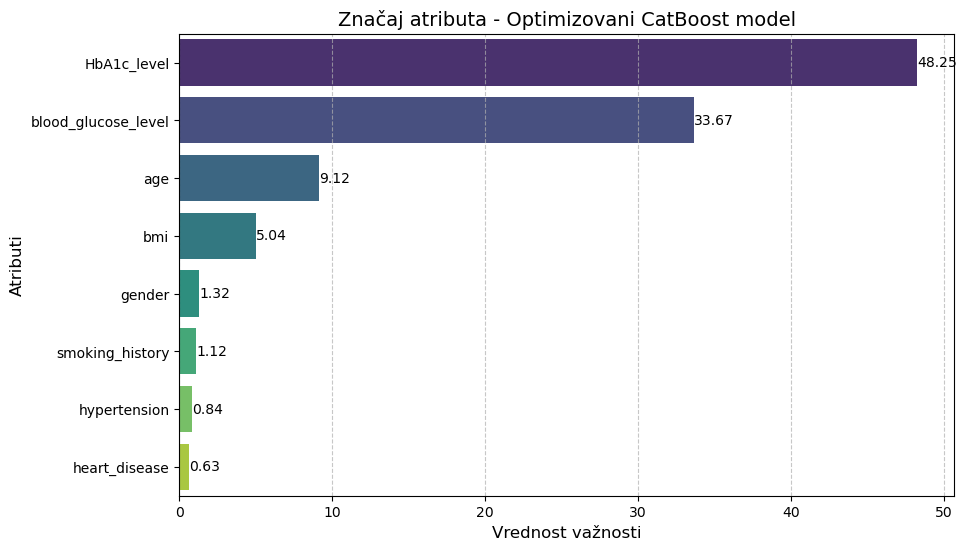

In [37]:
feature_importance = best_models["CatBoost"].get_feature_importance()
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df,hue='Feature', palette='viridis')

plt.title('Značaj atributa - Optimizovani CatBoost model', fontsize=14)
plt.xlabel('Vrednost važnosti', fontsize=12)
plt.ylabel('Atributi', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(fi_df['Importance']):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=10)

plt.show()

### SHAP vrednosti

SHAP Summary Plot - Uticaj atributa na dijagnozu dijabetesa (Klasa 1)


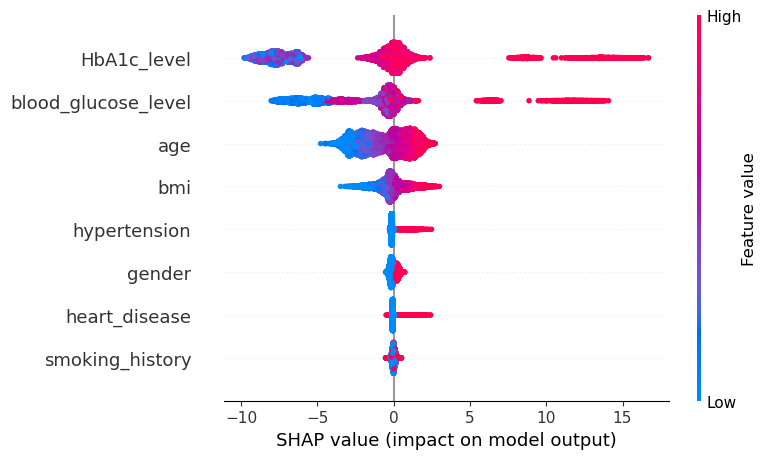

In [38]:
import shap

explainer = shap.TreeExplainer(best_models["CatBoost"])

shap_values = explainer.shap_values(X_test)

shap_to_plot = shap_values

print("SHAP Summary Plot - Uticaj atributa na dijagnozu dijabetesa (Klasa 1)")
shap.summary_plot(shap_to_plot, X_test, plot_type="dot")

SHAP grafikon potvrđuje nelinearnu zavisnost, dok ekstremno visoke vrednosti laboratorijskih testova skoro da garantuju dijagnozu, faktori poput godina i BMI-a služe kao dodatni faktori koji utiču na konačnu procenu rizika.

### LIME

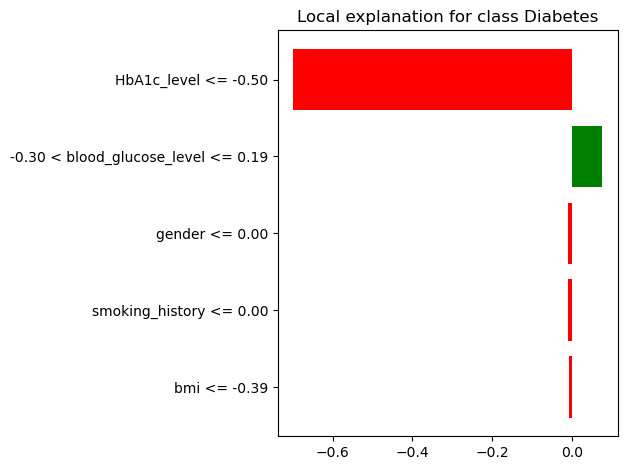

In [40]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_res.values,          
    feature_names=X_train_res.columns.tolist(),        
    class_names=['Not Diabetes', 'Diabetes'],
    mode='classification',
    discretize_continuous=True
)

i = 1
sample = X_test.iloc[i].values

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=best_models["CatBoost"].predict_proba, 
    num_features=5                                    
)

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()


U LIME analizi, zelena boja predstavlja atribute koji doprinose klasifikaciji u pozitivnu klasu (Diabetes), dok crvena boja označava faktore koji negiraju prisustvo bolesti i vuku predikciju ka negativnoj klasi (Not Diabetes)

In [41]:
preds = best_models["CatBoost"].predict(X_test)

fn_indices = [idx for idx, (actual, pred) in enumerate(zip(y_test, preds)) if actual == 1 and pred == 0]

print(f"Pronađeno je {len(fn_indices)} lažno negativnih rezultata.")
print(f"Primeri indeksa: {fn_indices[:10]}") # Prikazuje prvih 10
print(f"Vrednost u y_test za indeks 0: {y_test.iloc[0]}")
print(f"Predikcija modela za indeks 0: {preds[0]}")


tp_indices = [idx for idx, (actual, pred) in enumerate(zip(y_test, preds)) if actual == 1 and pred == 1]

print(f"Pronađeno je {len(tp_indices)} tačno pozitivnih.")
print(f"Primeri indeksa: {tp_indices[:10]}") 
print(f"Vrednost u y_test za indeks 40: {y_test.iloc[0]}")
print(f"Predikcija modela za indeks 40: {preds[40]}")

Pronađeno je 498 lažno negativnih rezultata.
Primeri indeksa: [0, 39, 58, 90, 172, 229, 268, 278, 337, 370]
Vrednost u y_test za indeks 0: 1
Predikcija modela za indeks 0: 0
Pronađeno je 1198 tačno pozitivnih.
Primeri indeksa: [40, 52, 82, 94, 99, 111, 130, 161, 166, 222]
Vrednost u y_test za indeks 40: 1
Predikcija modela za indeks 40: 1


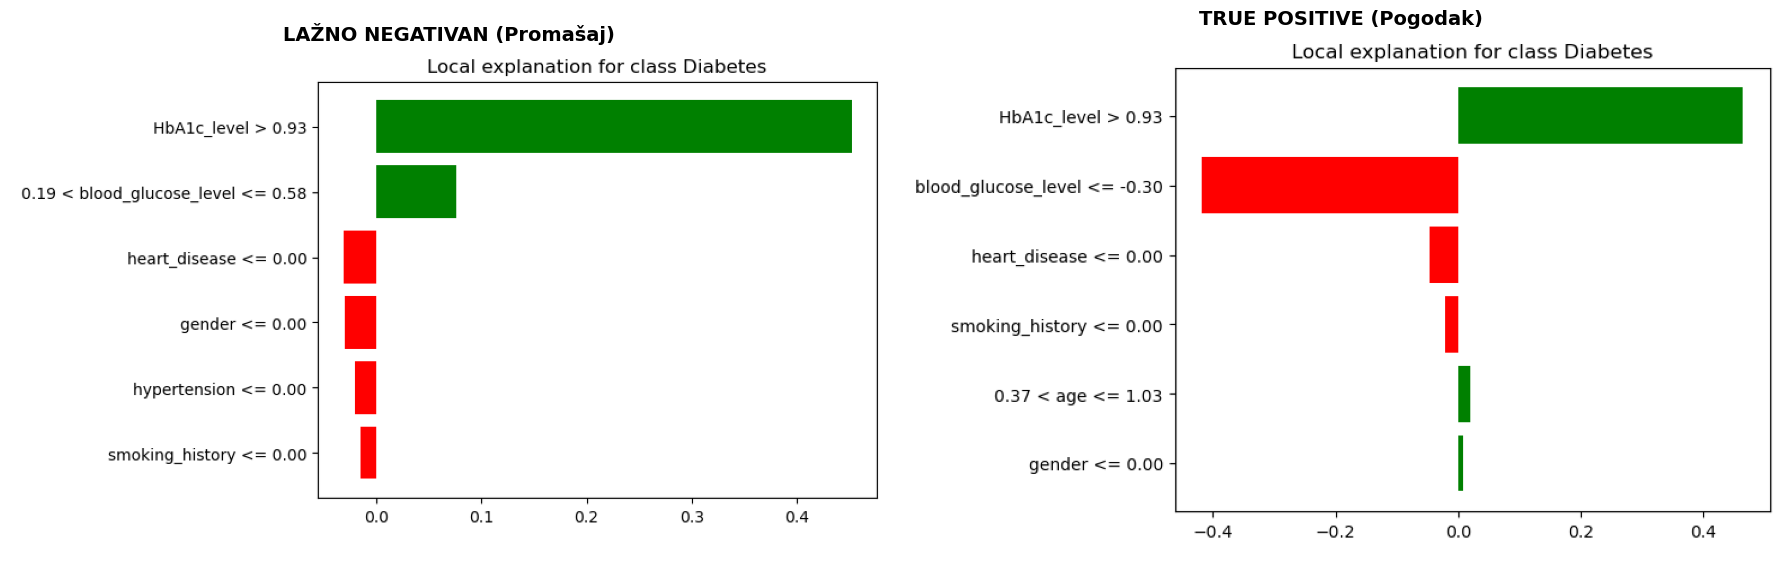

In [42]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#  (Promašaj)
exp_fn = explainer.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=best_models["CatBoost"].predict_proba,
    num_features=6
)
fig1 = exp_fn.as_pyplot_figure()
fig1.savefig('fn_plot.png', bbox_inches='tight')
plt.close(fig1) 
#  (Pogodak)
exp_tp = explainer.explain_instance(
    data_row=X_test.iloc[40].values,
    predict_fn=best_models["CatBoost"].predict_proba,
    num_features=6
)
fig2 = exp_tp.as_pyplot_figure()
fig2.savefig('tp_plot.png', bbox_inches='tight')
plt.close(fig2)

fig, ax = plt.subplots(1, 2, figsize=(18, 9))

img_fn = mpimg.imread('fn_plot.png')
img_tp = mpimg.imread('tp_plot.png')

ax[0].imshow(img_fn)
ax[0].axis('off')
ax[0].set_title("LAŽNO NEGATIVAN (Promašaj)", fontsize=14, fontweight='bold')

ax[1].imshow(img_tp)
ax[1].axis('off')
ax[1].set_title("TRUE POSITIVE (Pogodak)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

True Positive (Pacijent 40): Zelena traka za HbA1c_level > 0.93 je duža i ima jači ponder (skoro dopire do 0.5). Kod ovog pacijenta, šećer je bio toliko visok da je model to shvatio kao neoboriv dokaz.

False Negative (Pacijent 0): Iako je HbA1c_level takođe u rangu preko 0.93, njegova traka je za nijansu kraća. To znači da je vrednost bila "granična", što modelu ostavlja prostora za sumnju. Postoji više crvenih traka (heart_disease, hypertension, age) koje vuku vagu na stranu "Zdrav". Zbir tih malih crvenih traka je "pojeo" uticaj zelene trake.


In [43]:
import pandas as pd

numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

def get_patient_data(idx):
    row = X_test.iloc[idx].copy()
    
    scaled_vals = row[numeric_features].values.reshape(1, -1)
    
    unscaled_vals = scaler.inverse_transform(scaled_vals)[0]
    
    row[numeric_features] = unscaled_vals
    return row

p_fn = get_patient_data(0)   # Pacijent 0 (Promašaj)
p_tp = get_patient_data(40)  # Pacijent 40 (Pogodak)

prob_fn = best_models["CatBoost"].predict_proba(X_test.iloc[[0]])[0][1]
prob_tp = best_models["CatBoost"].predict_proba(X_test.iloc[[40]])[0][1]

poredjenje = pd.DataFrame({
    "Karakteristika": X_test.columns,
    "Pacijent 0 (Promašaj)": p_fn.values,
    "Pacijent 40 (Pogodak)": p_tp.values
})

print(poredjenje.to_string(index=False, float_format=lambda x: "{:.2f}".format(x)))
print("-" * 60)
print(f"VEROVATNOĆA DIJABETESA (Pacijent 0): {prob_fn*100:.2f}%")
print(f"VEROVATNOĆA DIJABETESA (Pacijent 40): {prob_tp*100:.2f}%")

     Karakteristika  Pacijent 0 (Promašaj)  Pacijent 40 (Pogodak)
             gender                   0.00                   0.00
                age                  40.00                  53.00
       hypertension                   0.00                   0.00
      heart_disease                   0.00                   0.00
    smoking_history                   0.00                   0.00
                bmi                  31.16                  35.67
        HbA1c_level                   6.60                   8.30
blood_glucose_level                 159.00                 126.00
------------------------------------------------------------
VEROVATNOĆA DIJABETESA (Pacijent 0): 4.27%
VEROVATNOĆA DIJABETESA (Pacijent 40): 100.00%


## Redukcija dimenzionalnosti 

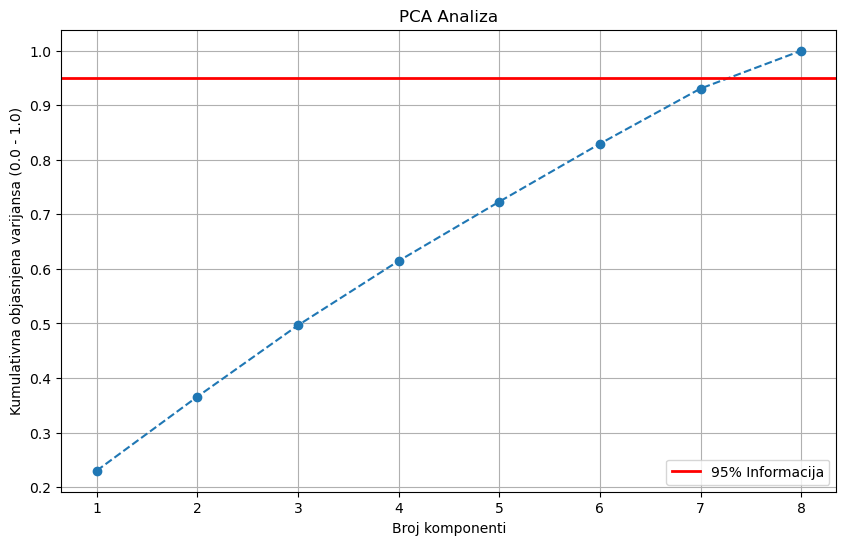

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker="o", linestyle='--')

plt.axhline(y=0.95, color='r', linestyle='-', linewidth=2, label='95% Informacija')

plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativna objasnjena varijansa (0.0 - 1.0)")
plt.title("PCA Analiza")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Analiza glavnih komponenti (PCA) sprovedena je u cilju ispitivanja strukture podataka i mogućnosti redukcije dimenzionalnosti. Rezultati pokazuju da je informacija o pacijentima ravnomerno raspoređena, pri čemu je potrebno zadržati 7 komponenti kako bi se objasnilo 93% varijanse skupa podataka. S obzirom na to da značajan pad varijanse nije uočen nakon prvih nekoliko komponenti, doneta je odluka da se zadrži svih 8 originalnih atributa.